# The goal of this notebook is to perform an interpretability analysis of a trained OAMFA model

This should mainly test if \mu and \Psi maps to physical phenomenoms, preferably the tru spectral signature of a material, and sensor noise.

#### **Data**
Two images: 
1) one that contains two clear materials (Ocean + Land) HYPSO-1_HSI_20250515T104003Z-l1a.nc <- From sula, allso conatins snow-pixels
2) one that contains (Ocean + Alge Ocean + Land) HYPSO-1_HSI_20250611T103127Z-l1a.nc <- Algebloom in skagerrak

Training-set: The whole images.\
Test-set: One pixel from each of the distinct biases (water, land, alge water).\

#### **Tests**
1) **Extracted \mu**
- Train the model on the image by streaming it
- Extract mu from each component after training 
- Sample one pixel that represents each of the distinct biases 
- Compare \mu to the pixel, both by pplotting and by calculating SAM

2) **Noise \Psi** 
(done in the notebook component_drift.ipynb)
- Plot \Psi after training on a normal image
- Inject noise to specific bands in an image
- stream the image, and plot the resulting \Psi
- Preferably, there is a spike in \Psi on the same band as where the noise was injected

3) **Covariance \Lambda**
- The goal should be to identify if \Lambda is capturing any specific inner ariance in a given class. I am uncertain how to test this.





In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from matplotlib.colors import ListedColormap
import matplotlib.patches as patches

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from otfp import MFA_OTFP
from hypso import Hypso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L2_NORMALIZATION = True  # Set to True to enable L2 normalization, False to disable

Loading baseline hypercube from ../data/interpretability_analysis/sula_2025-05-15T10-40-03Z-l1b.nc...
Successfully loaded | Shape: (598, 1092, 120)
Training Lines:  60 -> Shape: (598, 60, 120)
Testing Lines:   598 -> Shape: (598, 1032, 120)


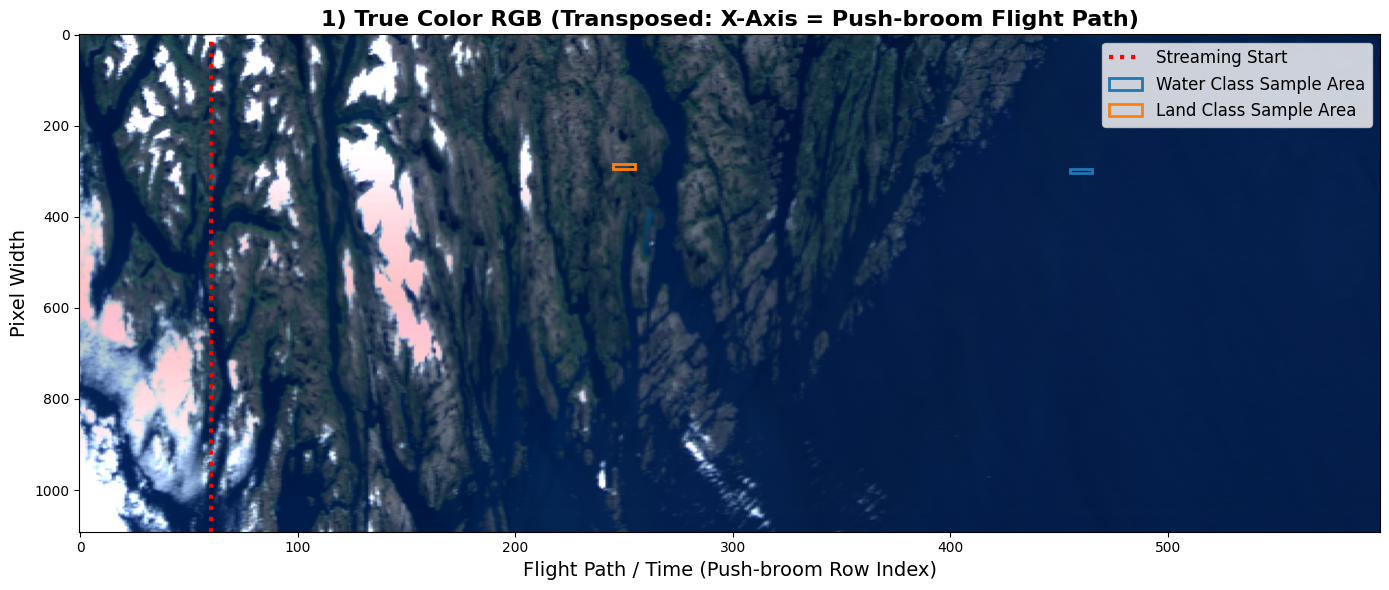

In [2]:
TRIVIAL_TEST = True  # Set to True to run the trivial test case, False to run the nontrivial one

# 0. FILE PATHS & CONFIG
if TRIVIAL_TEST:
    image_path = "../data/interpretability_analysis/sula_2025-05-15T10-40-03Z-l1b.nc" 
else:
    image_path = "../data/interpretability_analysis/skagerrak_bloom_2025-06-11T10-31-27Z-l1b.nc" 

N_TRAIN_LINES = 60

# 1. LOAD DATA 
print(f"Loading baseline hypercube from {image_path}...")
try:
    satobj = Hypso(image_path)
    cube = getattr(satobj, "l1b_cube", None)
    if cube is None:
        raise ValueError("Missing 'l1b_cube' data.")
    img_full = cube.values.astype(np.float32)
    print(f"Successfully loaded | Shape: {img_full.shape}")
except Exception as e:
    print(f"FATAL: Error processing {image_path}: {e}")
    sys.exit()

# 2. SPLIT DATA 
img_train = img_full[:, :N_TRAIN_LINES, :].copy()
img_test = img_full[:, N_TRAIN_LINES:, :].copy()
total_test_rows = img_test.shape[0]

print(f"Training Lines:  {N_TRAIN_LINES} -> Shape: {img_train.shape}")
print(f"Testing Lines:   {total_test_rows} -> Shape: {img_test.shape}")

# 3. SAMPLE PIXELS FOR INTERPRETABILITY 
AVERAGE_WINDOW = 5  # Number of rows to average for a smoother spectrum

# NOTE: These coordinates are (Row, Col) relative to the TEST set.
if TRIVIAL_TEST:
    samples_of_interest = [(400, 300), (190, 290)]
    sample_labels = ['Water Class Sample Area', 'Land Class Sample Area']
else:
    samples_of_interest = [(20, 950), (205, 290), (100, 100)]  # Adjust as needed for the nontrivial case
    sample_labels = ['Water Class Sample Area', 'Land Class Sample Area', 'Algae Bloom Sample Area']

pixel_spectrums = []
average_pixel_spectrums = []
for sample in samples_of_interest:
    pixel_spectrum = img_test[sample[0], sample[1], :]
    pixel_spectrums.append(pixel_spectrum)
    average_pixel_spectrum = np.mean(
        img_test[sample[0]:sample[0]+AVERAGE_WINDOW, 
                     sample[1], :], axis=0
    )
    average_pixel_spectrums.append(average_pixel_spectrum)


# 4. PLOTTING THE SETUP
# --- PRE-COMPUTE RGB IMAGE (Just like the second plot) ---
r_band, g_band, b_band = 70, 50, 30  
rgb_cube = img_full[:, :, [r_band, g_band, b_band]]

# Normalize the RGB image to [0, 1] using percentiles
p2, p98 = np.percentile(rgb_cube, (2, 98))
rgb_normalized = np.clip((rgb_cube - p2) / (p98 - p2 + 1e-8), 0, 1)

# Transpose the spatial dimensions from (Rows, Cols, 3) to (Cols, Rows, 3)
rgb_transposed = np.swapaxes(rgb_normalized, 0, 1)

# Create a wide horizontal figure 
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 

# Plot with aspect='auto' to stretch the image correctly
axes.imshow(rgb_transposed, aspect='auto')

axes.set_title("1) True Color RGB (Transposed: X-Axis = Push-broom Flight Path)", fontsize=16, fontweight='bold')
# The training line is now vertical (axvline) and tracks along the X-axis
axes.axvline(x=N_TRAIN_LINES, color='red', linestyle=':', linewidth=3, label="Streaming Start")

# Update labels to match the transposed orientation
axes.set_xlabel("Flight Path / Time (Push-broom Row Index)", fontsize=14)
axes.set_ylabel("Pixel Width", fontsize=14)

# Helper to place markers on the Transposed image 
def add_pixel_marker(ax, coord, color, label):
    # coord is (row, col) in the test set. 
    # Because we TRANSPOSED the image: X-axis = row, Y-axis = col.
    # We add N_TRAIN_LINES to the row because coord is relative to the img_test split
    x_pos = coord[0] + N_TRAIN_LINES - 5
    y_pos = coord[1] - 5
    
    rect = patches.Rectangle((x_pos, y_pos), 10, 10, 
                              linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

# Dynamically plot all samples using the tab10 colormap
sample_cmap = plt.get_cmap('tab10')

for i, coord in enumerate(samples_of_interest):
    color = sample_cmap(i % 10) 
    label = sample_labels[i] if i < len(sample_labels) else f'Sample Area {i+1}'
    add_pixel_marker(axes, coord, color, label)

axes.legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

## Training the model

In [3]:
# Your original code:
img_train = img_train.reshape(-1, img_train.shape[-1])  # Flatten to (num_pixels, num_bands)
img_train = torch.from_numpy(img_train).float().to(device)  # Convert to PyTorch tensor

MFA_OTFP_model=MFA_OTFP(
    n_channels=120, 
    device="cpu", 
    outlier_update_treshold=100,
    q_max=4,
    L2_normalization=L2_NORMALIZATION
)

MFA_OTFP_model.fit(img_train)

Model successfully updated! Added 4 components. Total (K) is now 4


## Streaming The system

In [4]:

h, w, d = img_test.shape

print(f"Streaming hyperspectral data (Shape: {img_test.shape})")

# --- 2. Initialize 2D Maps for the Plotting ---
assignment_map = np.zeros((h, w))
mahalanobis_map = np.zeros((h, w))

# FIX: Change to a list to track EVERY row where a spawn happens
current_k = MFA_OTFP_model.MFA.K  # Start with the baseline K value
baseline_k = current_k  # Store the baseline K for later comparison

# --- 3. Stream the data block-by-block ---
BLOCK_SIZE = 1
for t_row in range(0, h, BLOCK_SIZE):
    
    slice_data = img_test[t_row : t_row + BLOCK_SIZE, :, :]
    batch_flat = slice_data.reshape(-1, d)
    batch_tensor = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Unpack the 3 variables returned by your updated otfp.py
    assignments, distances, _ = MFA_OTFP_model.process_data_block(X=batch_tensor)
    
    # Move to CPU/NumPy
    assign_np = assignments.cpu().numpy().copy()
    dist_np = distances.cpu().numpy()
    
    # Manually mask outliers as -1 so they render as black in the plot
    outlier_mask = dist_np > MFA_OTFP_model.chi2_threshold
    assign_np[outlier_mask] = -1
    
    # Store in the 2D maps
    assignment_map[t_row:t_row + BLOCK_SIZE, :] = assign_np
    mahalanobis_map[t_row:t_row + BLOCK_SIZE, :] = dist_np
    
    # FIX: Append to the list every time K increases
    if MFA_OTFP_model.MFA.K > current_k:
        current_k = MFA_OTFP_model.MFA.K

print("\n--- STREAMING COMPLETE ---")
final_k = MFA_OTFP_model.MFA.K
print(f"Final Components (K): {final_k}")
print(f"Total New Components Spawned: {final_k - baseline_k}")

Streaming hyperspectral data (Shape: (598, 1032, 120))
Model successfully updated! Added 2 components. Total (K) is now 6
Model successfully updated! Added 1 components. Total (K) is now 7

--- STREAMING COMPLETE ---
Final Components (K): 7
Total New Components Spawned: 3


## Plotting the colour asignmentmap

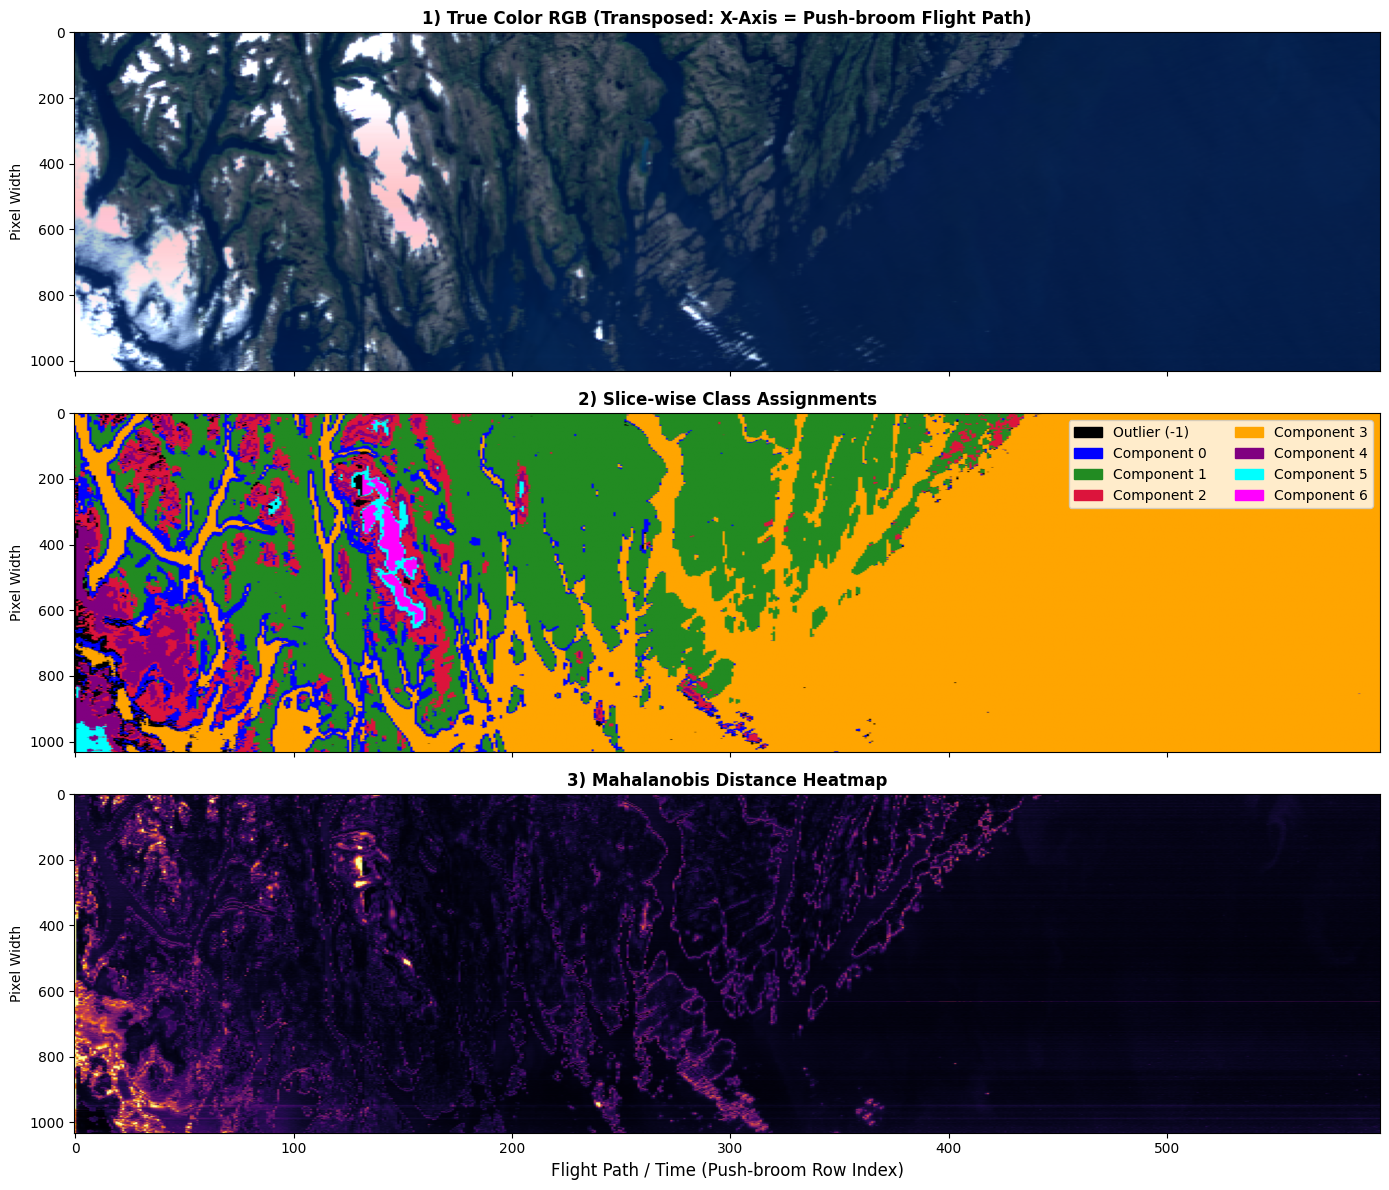

In [5]:
# Create 3 stacked subplots that share the same X-axis (Time/Flight Path)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Define Colormap: -1=Black (Outlier), 0=Blue, 1=Green, 2=Red, etc.
color_list = ['black', 'blue', 'forestgreen', 'crimson', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown']
# Limit the colormap based on the final number of components
cmap_classes = ListedColormap(color_list[:final_k+1])
cmap_classes.set_bad('white', 1.0) # Fallback for NaNs

# --- PRE-COMPUTE RGB IMAGE ---
# Select 3 bands to represent Red, Green, and Blue
r_band, g_band, b_band = 70, 50, 30  
rgb_cube = img_test[:, :, [r_band, g_band, b_band]]

# Normalize the RGB image to [0, 1] so matplotlib can display it
p2, p98 = np.percentile(rgb_cube, (2, 98))
rgb_normalized = np.clip((rgb_cube - p2) / (p98 - p2 + 1e-8), 0, 1)

# Transpose the spatial dimensions from (Rows, Cols, 3) to (Cols, Rows, 3)
rgb_transposed = np.swapaxes(rgb_normalized, 0, 1)

# --- Plot 1: Raw Image (Transposed) ---
ax1 = axes[0]
ax1.imshow(rgb_transposed, aspect='auto')
ax1.set_title("1) True Color RGB (Transposed: X-Axis = Push-broom Flight Path)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Pixel Width")

# --- Plot 2: Class Assignments (Transposed) & Custom Legend ---
ax2 = axes[1]
ax2.imshow(assignment_map.T, cmap=cmap_classes, aspect='auto', vmin=-1.5, vmax=final_k-0.5)

# Build custom legend elements
legend_elements = [patches.Patch(color=color_list[0], label='Outlier (-1)')]
for k in range(final_k):
    # Offset by 1 to skip the black outlier color
    color_idx = (k + 1) % len(color_list) 
    legend_elements.append(patches.Patch(color=color_list[color_idx], label=f'Component {k}'))

# Apply the constructed legend
ax2.legend(handles=legend_elements, loc="upper right", fontsize=10, ncol=max(1, final_k//3))
ax2.set_title("2) Slice-wise Class Assignments", fontsize=12, fontweight='bold')
ax2.set_ylabel("Pixel Width")

# --- Plot 3: Mahalanobis Distance Heatmap (Transposed) ---
ax3 = axes[2]
vmax_heat = MFA_OTFP_model.chi2_threshold * 2 
im3 = ax3.imshow(mahalanobis_map.T, cmap='inferno', aspect='auto', vmin=0, vmax=vmax_heat)

ax3.set_title("3) Mahalanobis Distance Heatmap", fontsize=12, fontweight='bold')
ax3.set_xlabel("Flight Path / Time (Push-broom Row Index)", fontsize=12)
ax3.set_ylabel("Pixel Width")

plt.tight_layout()
plt.show()

## Plotting \mu against the sampled pixels

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
C:\Users\trygvemt\AppData\Local\Temp\ipykernel_6756\2475105440.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(wavelengths_nm, clamped_mean, label=f'Component {k} $\mu$', color=c, linewidth=2.0, alpha=0.9)
C:\Users\trygvemt\AppData\Local\Temp\ipykernel_6756\2475105440.py:51: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Learned $\mu$ and Noise Envelope vs. Real Sampled Pixels", fontweight='bold', fontsize=14)


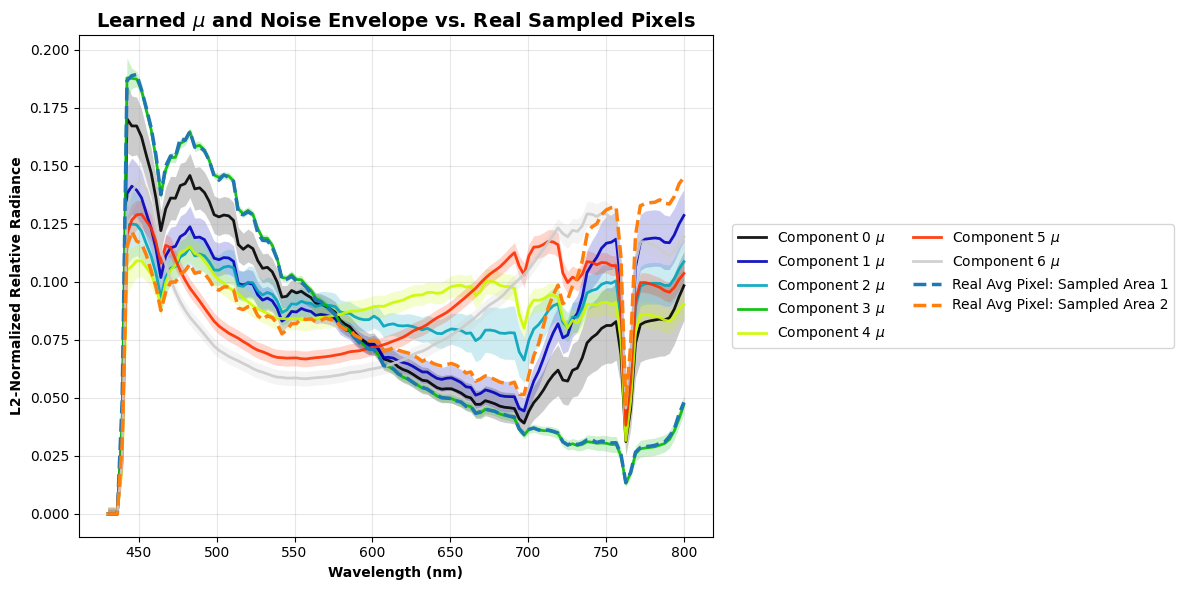

In [6]:
# Extract parameters from the loaded/trained model
mfa_model = MFA_OTFP_model.MFA
K = mfa_model.K
wavelengths_nm = np.linspace(430, 800, 120)

physical_means = mfa_model.mu.cpu().detach().numpy() 
lambdas = mfa_model.Lambda.cpu().detach().numpy()          # Shape: (K, D, q)
psi = torch.exp(mfa_model.log_psi).cpu().detach().numpy()  # Shape: (K, D)

fig, ax = plt.subplots(figsize=(12, 6))
model_cmap = plt.get_cmap('nipy_spectral')

# --- 1. Plot the learned model components ---
for k in range(K):
    color_fraction = k / max(1, K - 1) 
    c = model_cmap(color_fraction)
    
    # Calculate Total Variance per band
    lambda_variance = np.sum(lambdas[k] ** 2, axis=1) # Shape: (D,)
    total_variance = lambda_variance + psi[k]
    std_dev = np.sqrt(total_variance)
    
    clamped_mean = np.maximum(physical_means[k], 0)
    lower_bound = np.maximum(clamped_mean - std_dev, 0)
    upper_bound = clamped_mean + std_dev
    
    # Plot the mean line and Bayesian variance envelope
    ax.plot(wavelengths_nm, clamped_mean, label=f'Component {k} $\mu$', color=c, linewidth=2.0, alpha=0.9)
    ax.fill_between(wavelengths_nm, lower_bound, upper_bound, color=c, alpha=0.2, linewidth=0)

# --- 2. Plot the sampled pixels dynamically ---
# Use a distinct colormap for the drawn samples so they don't blend in with the components
sample_cmap = plt.get_cmap('tab10') 
num_samples = len(average_pixel_spectrums)

for i, spec in enumerate(average_pixel_spectrums):
    # Ensure apples-to-apples mapping: Normalize sample if model was normalized
    if L2_NORMALIZATION:
        norm = np.linalg.norm(spec)
        if norm > 0:
            spec = spec / norm
            
    # Dynamically grab a color and generate a generic label
    sample_color = sample_cmap(i % 10) # Cycles through 10 distinct categorical colors
    sample_label = f'Sampled Area {i+1}'
            
    ax.plot(wavelengths_nm, spec, color=sample_color, linestyle='--', linewidth=2.5, 
            label=f'Real Avg Pixel: {sample_label}')

# --- 3. Polish and Labels ---
ax.set_title("Learned $\mu$ and Noise Envelope vs. Real Sampled Pixels", fontweight='bold', fontsize=14)
ax.set_xlabel("Wavelength (nm)", fontweight='bold')

if L2_NORMALIZATION:
    ax.set_ylabel("L2-Normalized Relative Radiance", fontweight='bold')
else:
    ax.set_ylabel("Raw Radiance", fontweight='bold')

ax.grid(True, alpha=0.3)

# Dynamically adjust legend based on total items (components + drawn samples)
total_legend_items = K + num_samples
if total_legend_items > 15:
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=3)
elif total_legend_items > 8:
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=2)
else:
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=1)

plt.tight_layout()
plt.show()